# E17 · Meta-analysis: learning from a database of studies that never shares a patient

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Three benchmark meta-analysis datasets from the `metadat` database: 13 BCG vaccine trials (Colditz et al. 1994), 16 magnesium-after-infarction trials (Egger et al. 2001), 56 school-calendar studies nested in 11 districts (Konstantopoulos 2011) |
| **You will learn** | Why a 2 x 2 table is a *sufficient statistic* and what that means for privacy · two-stage (normal) vs one-stage (binomial) random-effects models · forest plots with shrinkage, pooled diamonds and **prediction intervals** · $\tau$ and $I^2$ as posteriors · meta-regression on a study-level moderator · leave-one-out influence and cumulative meta-analysis · funnel plots, small-study effects and a Bayesian Egger model on the magnesium saga · what a database that **suppresses small cells** or adds **differential-privacy noise** does to the inference, and how to model both · three-level models for nested studies |

A meta-analysis is the original privacy-preserving analysis. Each study keeps its patients
and publishes a handful of numbers - how many people in each arm, how many had the event -
and the analyst pools those numbers. The `metadat` database (the benchmark collection behind
the R package `metafor`) holds hundreds of such tables, and not one of them contains a person.

This notebook takes that seriously in both directions. First, the *good* news: for the
models used here the published table loses nothing relative to the individual records, so
there is no privacy-vs-accuracy trade-off at all. Then the *cost* of going further: when a
database suppresses small counts or adds calibrated noise before release, the numbers it
publishes are no longer the sufficient statistics, and an analysis that ignores that is
not just noisier but wrong. Both mechanisms are modelled explicitly, and the loss of
information is measured rather than guessed. Along the way, the usual visual tools of the
trade are built by hand: forest, funnel, bubble, influence and cumulative plots.

In [1]:
import logging

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from scipy import stats

from pymc_challenges import data

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)  # this notebook runs ~50 fits: no banner per fit
BLUE, ORANGE, AQUA, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86"
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")


def fit(model, **kw):
    """One place for the sampler settings; every fit reports its divergences."""
    with model:
        idata = pm.sample(target_accept=0.95, random_seed=RANDOM_SEED, progressbar=False, **kw)
    print(f"  {model.name or 'model'}: divergences = {int(idata.sample_stats['diverging'].sum())}")
    return idata


def stacked(da):
    return da.stack(sample=("chain", "draw")).transpose("sample", ...).to_numpy()

PyMC 6.3.2, ArviZ 1.3.0


## 1 · The database

Thirteen trials of the BCG vaccine against tuberculosis, published between 1948 and 1980 and
run on four continents. Each is a 2 x 2 table plus two study-level facts: the year and the absolute
latitude of the site (BCG is known to work better far from the equator, plausibly because
exposure to environmental mycobacteria near the equator gives some natural immunity that the
vaccine cannot add to). That is *all* we get: 13 rows.

In [2]:
data.describe("bcg")
bcg = data.load("bcg")
bcg["n_vacc"] = bcg.tpos + bcg.tneg
bcg["n_ctrl"] = bcg.cpos + bcg.cneg
bcg["rate_vacc"] = 1000 * bcg.tpos / bcg.n_vacc
bcg["rate_ctrl"] = 1000 * bcg.cpos / bcg.n_ctrl
bcg[["author", "year", "ablat", "alloc", "tpos", "n_vacc", "cpos", "n_ctrl", "rate_vacc", "rate_ctrl"]].round(1)

bcg: 13 trials as 2x2 tables (TB cases and non-cases in vaccinated / control arms), year, latitude, allocation.
  source: Colditz et al. (1994), BCG vaccine against tuberculosis; the `metafor`/`metadat` benchmark.
  url:    https://raw.githubusercontent.com/wviechtb/metadat/master/data-raw/dat.bcg.txt


,author,year,ablat,alloc,tpos,n_vacc,cpos,n_ctrl,rate_vacc,rate_ctrl
0,Aronson,1948,44,random,4,123,11,139,32.5,79.1
1,Ferguson & Simes,1949,55,random,6,306,29,303,19.6,95.7
2,Rosenthal et al,1960,42,random,3,231,11,220,13.0,50.0
3,Hart & Sutherland,1977,52,random,62,13598,248,12867,4.6,19.3
4,Frimodt-Moller et al,1973,13,alternate,33,5069,47,5808,6.5,8.1
5,Stein & Aronson,1953,44,alternate,180,1541,372,1451,116.8,256.4
6,Vandiviere et al,1973,19,random,8,2545,10,629,3.1,15.9
7,TPT Madras,1980,13,random,505,88391,499,88391,5.7,5.6
8,Coetzee & Berjak,1968,27,random,29,7499,45,7277,3.9,6.2
9,Rosenthal et al,1961,42,systematic,17,1716,65,1665,9.9,39.0


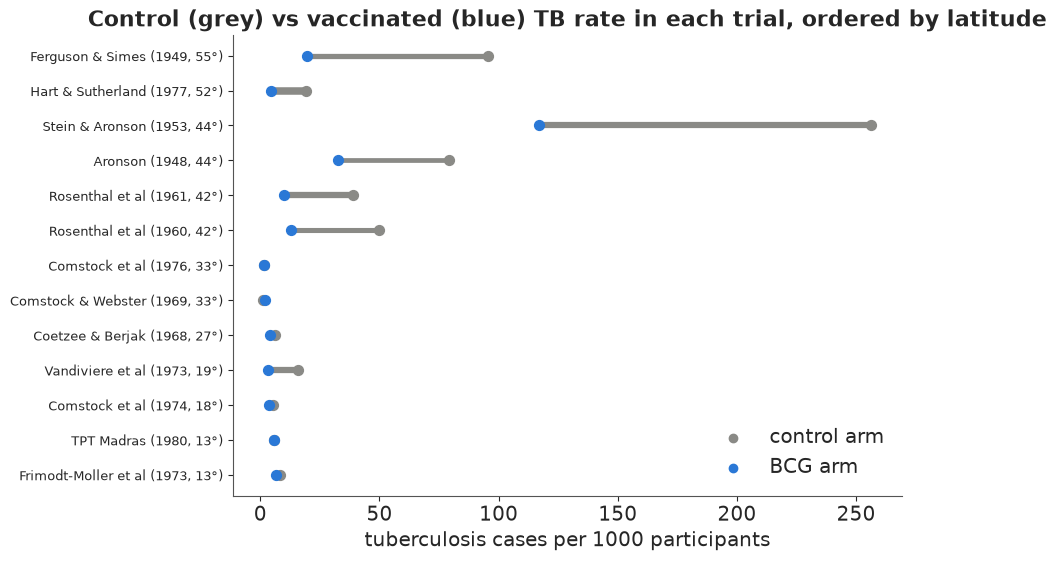

In [3]:
order = np.argsort(bcg.ablat.to_numpy())
fig, ax = plt.subplots(figsize=(9, 5.5))
for k, i in enumerate(order):
    r = bcg.iloc[i]
    ax.plot([r.rate_ctrl, r.rate_vacc], [k, k], color=GREY, lw=1 + np.log10(r.n_vacc + r.n_ctrl), zorder=1)
    ax.scatter(r.rate_ctrl, k, color=GREY, s=50, zorder=2)
    ax.scatter(r.rate_vacc, k, color=BLUE, s=50, zorder=3)
ax.set(yticks=range(len(bcg)), xlabel="tuberculosis cases per 1000 participants",
       title="Control (grey) vs vaccinated (blue) TB rate in each trial, ordered by latitude")
ax.set_yticklabels([f"{bcg.author[i]} ({bcg.year[i]}, {bcg.ablat[i]}°)" for i in order], fontsize=9)
ax.scatter([], [], color=GREY, label="control arm")
ax.scatter([], [], color=BLUE, label="BCG arm")
ax.legend(loc="lower right");

The picture already contains the whole story: the vaccine arm is to the left of the control
arm in eleven of thirteen trials, the gap is larger at high latitude, and the trials differ
enormously in size (the line thickness): from 260 to 177,000 participants.

### Why the table loses nothing: sufficient statistics

Suppose we *did* have the individual records - one row per participant with arm and
outcome. For a binary outcome and a model whose parameters are per-arm probabilities, the
likelihood of those records is $\prod_i p_{\text{arm}(i)}^{y_i}(1-p_{\text{arm}(i)})^{1-y_i}$,
which depends on the data only through the count of events per arm. The 2 x 2 table is
a **sufficient statistic**: every posterior we could compute from the records we can compute
from the table. Let us check that literally, on the first trial.

In [4]:
a, b, c, d = (bcg[col].to_numpy(float) for col in ["tpos", "tneg", "cpos", "cneg"])
i = 0
records = np.r_[np.ones(int(a[i])), np.zeros(int(b[i]))]  # the participant-level 0/1 outcomes, BCG arm

p_test = 0.03
lp_individual = pm.logp(pm.Bernoulli.dist(p=p_test), records).sum().eval()
lp_table = pm.logp(pm.Binomial.dist(n=a[i] + b[i], p=p_test), a[i]).eval()
log_binom_coef = stats.binom(a[i] + b[i], p_test).logpmf(a[i]) - (a[i] * np.log(p_test) + b[i] * np.log(1 - p_test))
print(f"individual records: {lp_individual:.3f}   table: {lp_table:.3f}   "
      f"difference = log binomial coefficient = {log_binom_coef:.3f} (a constant, so the posteriors agree)")

individual records: -17.651   table: -1.629   difference = log binomial coefficient = 16.021 (a constant, so the posteriors agree)


The two log-likelihoods differ by a constant that does not depend on $p$, so every posterior
is identical. This is why the published table is, for this model, a *lossless* and
*anonymous* summary: the privacy comes free. (The claim has limits: it needs the model to be
a function of the arm-level counts only. Patient-level covariates, time-to-event outcomes
or interactions between a treatment and an individual's characteristics need more than the
table - that is where individual-participant-data meta-analysis, and its privacy problems,
begin.)

## 2 · Two ways to pool: two-stage and one-stage

**Two-stage.** Reduce each trial to a log odds ratio $y_k$ and its standard error $s_k$,
then treat $y_k \sim \text{Normal}(\theta_k, s_k)$ with the trial effects drawn from a
population: $\theta_k \sim \text{Normal}(\mu, \tau)$. $\mu$ is the average effect, $\tau$ the
between-trial heterogeneity. This is the model everyone learns first; it needs a normal
approximation and, if any cell is zero, a "continuity correction".

**One-stage.** Keep the counts. Each arm's cases are Binomial with a trial-specific
control-arm log odds $\alpha_k$ and the same $\theta_k$ on top for the vaccine arm. Exact
likelihood, no corrections, small trials handled honestly. It is also the model to which the
sufficiency argument above applies.

Priors: $\mu \sim \text{Normal}(0, 1.5)$ says an odds ratio between 1/20 and 20 is plausible;
$\tau \sim \text{HalfNormal}(1)$ allows trial effects to differ by a factor of $e^{\pm 2}$
around the mean, which for vaccine trials is generous. Both models are non-centred.

In [5]:
y = np.log(a * d / (b * c))                      # log odds ratio (no zero cells in BCG)
se = np.sqrt(1 / a + 1 / b + 1 / c + 1 / d)
K = len(bcg)
coords = {"trial": bcg.author.to_numpy(dtype=object)}

with pm.Model(coords=coords, name="two_stage") as two_stage:
    mu = pm.Normal("mu", 0, 1.5)
    tau = pm.HalfNormal("tau", 1)
    z = pm.Normal("z", 0, 1, dims="trial")
    theta = pm.Deterministic("theta", mu + tau * z, dims="trial")
    pm.Normal("y", theta, se, observed=y, dims="trial")
    pm.Deterministic("theta_new", mu + tau * pm.Normal("z_new", 0, 1))  # a trial not yet run
idata_2 = fit(two_stage)


def one_stage_model(cases_t, n_t, cases_c, n_c, names, extra=None):
    """Binomial random-effects model; `extra` adds a term to theta from (model) -> tensor."""
    with pm.Model(coords={"trial": names}, name="one_stage") as m:
        mu = pm.Normal("mu", 0, 1.5)
        tau = pm.HalfNormal("tau", 1)
        z = pm.Normal("z", 0, 1, dims="trial")
        shift = extra(m) if extra is not None else 0.0
        theta = pm.Deterministic("theta", mu + shift + tau * z, dims="trial")
        alpha = pm.Normal("alpha", -4, 2, dims="trial")  # control-arm log odds of TB
        pm.Binomial("cases_c", n=n_c, p=pm.math.invlogit(alpha), observed=cases_c, dims="trial")
        pm.Binomial("cases_t", n=n_t, p=pm.math.invlogit(alpha + theta), observed=cases_t, dims="trial")
        pm.Deterministic("theta_new", mu + tau * pm.Normal("z_new", 0, 1))
    return m


one_stage = one_stage_model(a, a + b, c, c + d, coords["trial"])
idata_1 = fit(one_stage)

  two_stage: divergences = 0


  one_stage: divergences = 0


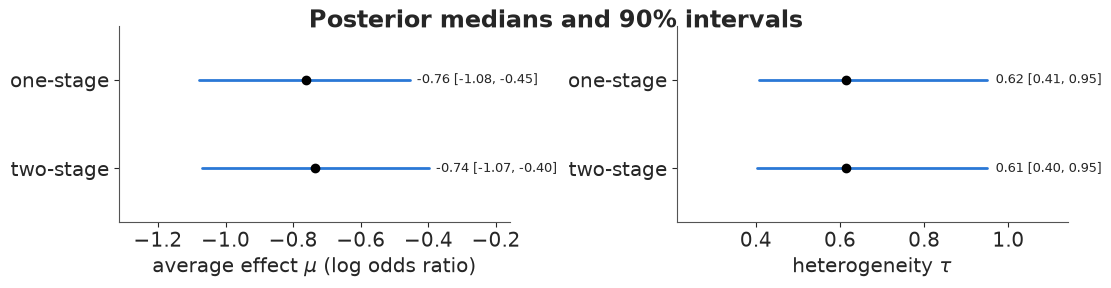

In [6]:
def summarise(idata, names, prefix=""):
    q = [0.05, 0.5, 0.95]
    return {n: np.quantile(stacked(idata.posterior[prefix + n]), q) for n in names}


fig, axes = plt.subplots(1, 2, figsize=(11, 2.6))
for ax, var, xl in [(axes[0], "mu", "average effect $\\mu$ (log odds ratio)"), (axes[1], "tau", "heterogeneity $\\tau$")]:
    for k, (name, idata, pre) in enumerate([("two-stage (normal)", idata_2, "two_stage::"), ("one-stage (binomial)", idata_1, "one_stage::")]):
        lo, med, hi = summarise(idata, [var], pre)[var]
        ax.plot([lo, hi], [k, k], color=BLUE, lw=2)
        ax.scatter(med, k, color="k", zorder=3)
        ax.text(hi + 0.02, k, f"{med:.2f} [{lo:.2f}, {hi:.2f}]", va="center", fontsize=9)
    ax.set(yticks=[0, 1], yticklabels=["two-stage", "one-stage"], xlabel=xl, ylim=(-0.6, 1.6))
    ax.margins(x=0.35)
fig.suptitle("Posterior medians and 90% intervals", y=1.05);

The two agree here because no trial is tiny and no cell is empty; when either fails, the
one-stage model is the one to trust, and it is the one used from now on.

### The forest plot, done properly

A forest plot shows each trial's own estimate and, in a Bayesian version, its *shrunken*
posterior, then the pooled effect as a diamond. The line most forest plots omit is the
**prediction interval**: where the effect of the *next* trial would fall. With $\tau$ this
large it is several times wider than the interval for $\mu$, and it is the interval a
public-health official planning a new BCG programme actually needs.

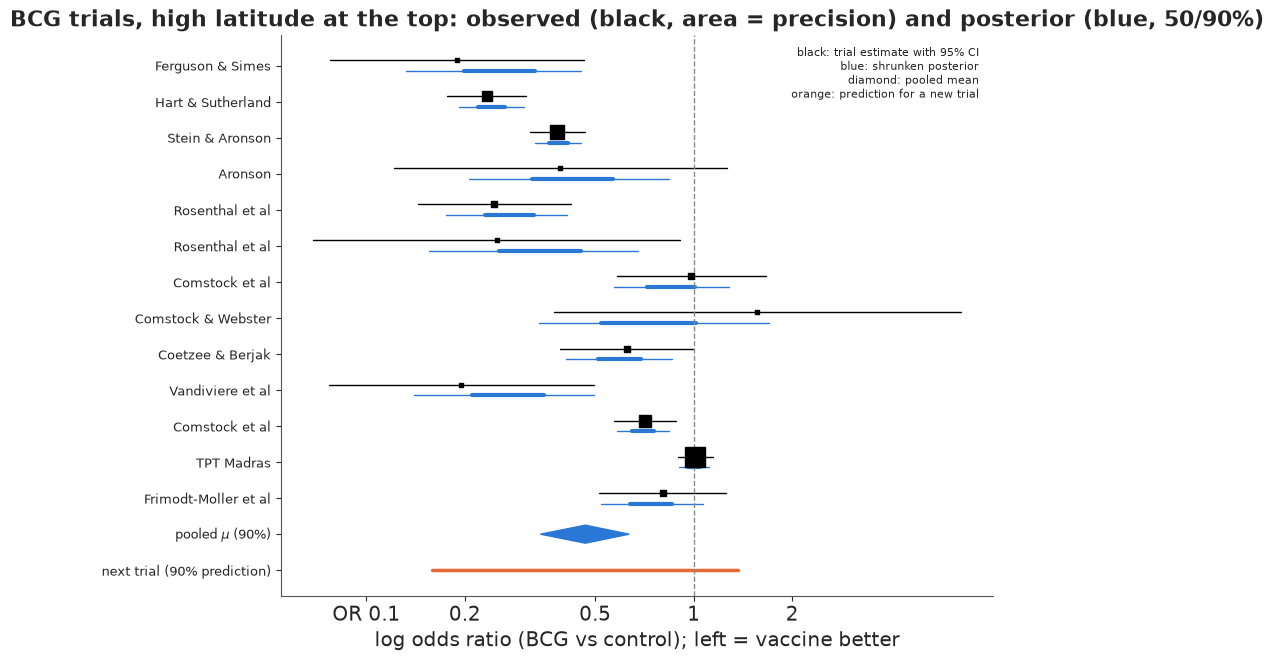

In [7]:
def forest(ax, idata, names, y_obs, se_obs, prefix, order=None, title=""):
    TH = stacked(idata.posterior[prefix + "theta"])
    MU = stacked(idata.posterior[prefix + "mu"])
    NEW = stacked(idata.posterior[prefix + "theta_new"])
    order = np.arange(len(names)) if order is None else order
    yy = np.arange(len(names))[::-1] + 2
    for row, i in zip(yy, order):
        ax.plot([y_obs[i] - 1.96 * se_obs[i], y_obs[i] + 1.96 * se_obs[i]], [row + 0.15, row + 0.15], color="k", lw=1)
        ax.scatter(y_obs[i], row + 0.15, color="k", s=8 + 200 / se_obs[i]**2 / (1 / se_obs**2).max(), marker="s", zorder=3)
        lo, q1, q3, hi = np.quantile(TH[:, i], [0.05, 0.25, 0.75, 0.95])
        ax.plot([lo, hi], [row - 0.15, row - 0.15], color=BLUE, lw=1)
        ax.plot([q1, q3], [row - 0.15, row - 0.15], color=BLUE, lw=3)
    lo, med, hi = np.quantile(MU, [0.05, 0.5, 0.95])
    ax.fill([lo, med, hi, med], [1, 1.25, 1, 0.75], color=BLUE)
    plo, phi = np.quantile(NEW, [0.05, 0.95])
    ax.plot([plo, phi], [0, 0], color=ORANGE, lw=2.5)
    ax.axvline(0, color=GREY, lw=1, ls="--")
    ax.set(yticks=np.r_[yy, 1, 0], xlabel="log odds ratio (BCG vs control); left = vaccine better", title=title)
    ax.set_yticklabels(list(np.asarray(names)[order]) + ["pooled $\\mu$ (90%)", "next trial (90% prediction)"], fontsize=9)
    ax.set_xticks(np.log([0.1, 0.2, 0.5, 1, 2]))
    ax.set_xticklabels(["OR 0.1", "0.2", "0.5", "1", "2"])
    return ax


fig, ax = plt.subplots(figsize=(9, 6.5))
forest(ax, idata_1, coords["trial"], y, se, "one_stage::", order=order[::-1],
       title="BCG trials, high latitude at the top: observed (black, area = precision) and posterior (blue, 50/90%)")
ax.text(0.98, 0.98, "black: trial estimate with 95% CI\nblue: shrunken posterior\ndiamond: pooled mean\norange: prediction for a new trial",
        transform=ax.transAxes, fontsize=8, va="top", ha="right");

## 3 · Heterogeneity is the result, not a nuisance

$\tau$ is usually reported once and then ignored. Three displays that make it speak:

1. **$\tau$ and $I^2$ as posteriors.** $I^2$ is the share of the variation in observed
   effects that is heterogeneity rather than sampling noise; it is a function of $\tau$ and
   the trials' precisions, so it has a posterior too.
2. **The next trial.** The predictive distribution of $\theta_{\text{new}}$ against the
   posterior of $\mu$: the first is what happens somewhere new, the second is a population
   average nobody will ever observe.
3. **Shrinkage against precision.** How far each trial is pulled towards the mean, plotted
   against its standard error: imprecise trials move a long way, precise ones barely.

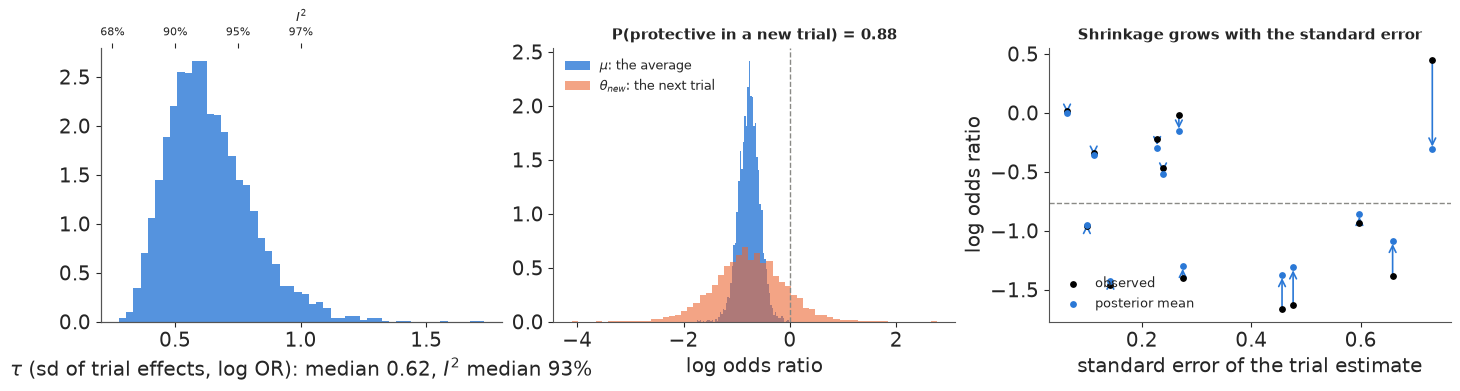

In [8]:
w = 1 / se**2
s2_typical = (K - 1) * w.sum() / (w.sum()**2 - (w**2).sum())  # Higgins & Thompson's typical within-trial variance
TAU = stacked(idata_1.posterior["one_stage::tau"])
MU = stacked(idata_1.posterior["one_stage::mu"])
NEW = stacked(idata_1.posterior["one_stage::theta_new"])
I2 = TAU**2 / (TAU**2 + s2_typical)
TH_mean = stacked(idata_1.posterior["one_stage::theta"]).mean(0)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
axes[0].hist(TAU, bins=50, color=BLUE, alpha=0.8, density=True)
axes[0].set(xlabel=f"$\\tau$ (sd of trial effects, log OR): median {np.median(TAU):.2f}, $I^2$ median {np.median(I2):.0%}")
ax2 = axes[0].twiny()
ax2.set_xlim(axes[0].get_xlim())
tau_ticks = np.array([0.25, 0.5, 0.75, 1.0])
ax2.set_xticks(tau_ticks)
ax2.set_xticklabels([f"{t**2 / (t**2 + s2_typical):.0%}" for t in tau_ticks], fontsize=8)
ax2.set_xlabel("$I^2$", fontsize=9)

axes[1].hist(MU, bins=60, color=BLUE, alpha=0.8, density=True, label="$\\mu$: the average")
axes[1].hist(NEW, bins=60, color=ORANGE, alpha=0.6, density=True, label="$\\theta_{new}$: the next trial")
axes[1].axvline(0, color=GREY, ls="--", lw=1)
axes[1].set(xlabel="log odds ratio")
axes[1].set_title(f"P(protective in a new trial) = {(NEW < 0).mean():.2f}", fontsize=11)
axes[1].legend(fontsize=9)

for i in range(K):
    axes[2].annotate("", xy=(se[i], TH_mean[i]), xytext=(se[i], y[i]),
                     arrowprops=dict(arrowstyle="->", color=BLUE, lw=1.2))
axes[2].scatter(se, y, color="k", s=15, zorder=3, label="observed")
axes[2].scatter(se, TH_mean, color=BLUE, s=15, zorder=3, label="posterior mean")
axes[2].axhline(np.median(MU), color=GREY, ls="--", lw=1)
axes[2].set(xlabel="standard error of the trial estimate", ylabel="log odds ratio")
axes[2].set_title("Shrinkage grows with the standard error", fontsize=11)
axes[2].legend(fontsize=9, loc="lower left");

## 4 · Meta-regression: explaining the heterogeneity

A study-level covariate turns $\mu$ into a line: $\theta_k = \mu + \beta\,(\text{lat}_k -
\overline{\text{lat}}) + \tau z_k$. If latitude explains the differences between trials, the
*residual* $\tau$ shrinks. The bubble plot (area = precision) is the standard display; the
two bands are, again, the line and the prediction for a new trial at that latitude.

  one_stage: divergences = 2
beta: -0.031 per degree of latitude, 90% [-0.043, -0.018]
tau: 0.62 -> 0.24 with latitude in the model


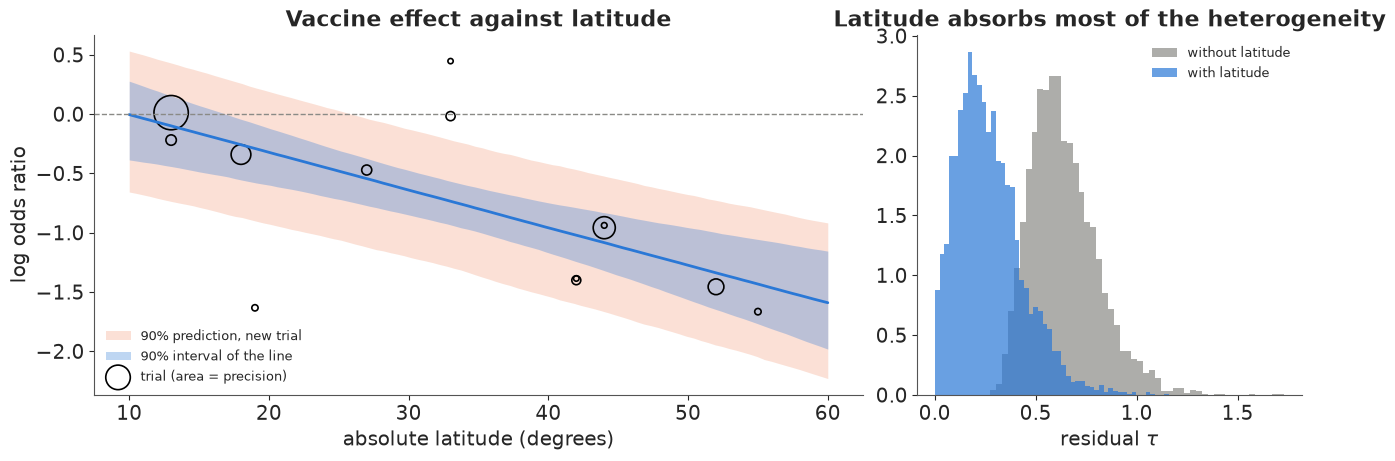

In [9]:
lat_c = (bcg.ablat - bcg.ablat.mean()).to_numpy(float)
metareg = one_stage_model(a, a + b, c, c + d, coords["trial"],
                          extra=lambda m: pm.Normal("beta", 0, 0.1) * lat_c)
idata_r = fit(metareg)
BETA = stacked(idata_r.posterior["one_stage::beta"])
MU_r = stacked(idata_r.posterior["one_stage::mu"])
TAU_r = stacked(idata_r.posterior["one_stage::tau"])
print(f"beta: {np.median(BETA):.3f} per degree of latitude, 90% [{np.quantile(BETA, 0.05):.3f}, {np.quantile(BETA, 0.95):.3f}]")
print(f"tau: {np.median(TAU):.2f} -> {np.median(TAU_r):.2f} with latitude in the model")

lat_grid = np.linspace(10, 60, 100)
line = MU_r[:, None] + BETA[:, None] * (lat_grid - bcg.ablat.mean())
new = line + TAU_r[:, None] * rng.normal(size=(len(MU_r), 1))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [2, 1]})
ax = axes[0]
ax.fill_between(lat_grid, *np.quantile(new, [0.05, 0.95], axis=0), color=ORANGE, alpha=0.2, lw=0, label="90% prediction, new trial")
ax.fill_between(lat_grid, *np.quantile(line, [0.05, 0.95], axis=0), color=BLUE, alpha=0.3, lw=0, label="90% interval of the line")
ax.plot(lat_grid, np.median(line, axis=0), color=BLUE, lw=2)
ax.scatter(bcg.ablat, y, s=600 * w / w.max() + 10, facecolor="none", edgecolor="k", lw=1.2, label="trial (area = precision)")
ax.axhline(0, color=GREY, ls="--", lw=1)
ax.set(xlabel="absolute latitude (degrees)", ylabel="log odds ratio", title="Vaccine effect against latitude")
ax.legend(fontsize=9, loc="lower left")
axes[1].hist(TAU, bins=50, color=GREY, alpha=0.7, density=True, label="without latitude")
axes[1].hist(TAU_r, bins=50, color=BLUE, alpha=0.7, density=True, label="with latitude")
axes[1].set(xlabel="residual $\\tau$", title="Latitude absorbs most of the heterogeneity")
axes[1].legend(fontsize=9);

## 5 · Which trials drive the answer, and when did we know?

Two questions a reviewer always asks, both answered by refitting. **Leave-one-out
influence**: drop each trial and refit - which trial, if removed, moves $\mu$ the most?
**Cumulative meta-analysis**: add trials in the order they were published - when did the
evidence become conclusive, and did the later trials change the picture? With a one-stage
model that fits in two seconds, 25 refits are cheap.

In [10]:
def mu_summary(idata):
    m = stacked(idata.posterior["one_stage::mu"])
    return np.quantile(m, [0.05, 0.5, 0.95]), (m < 0).mean()


loo_rows = []
for k in range(K):
    keep = np.arange(K) != k
    m_k = one_stage_model(a[keep], (a + b)[keep], c[keep], (c + d)[keep], coords["trial"][keep])
    with m_k:
        id_k = pm.sample(target_accept=0.95, random_seed=RANDOM_SEED, progressbar=False)
    loo_rows.append((bcg.author[k], *mu_summary(id_k)))

by_year = np.argsort(bcg.year.to_numpy(), kind="stable")
cum_rows = []
for n_trials in range(2, K + 1):
    keep = by_year[:n_trials]
    m_k = one_stage_model(a[keep], (a + b)[keep], c[keep], (c + d)[keep], coords["trial"][keep])
    with m_k:
        id_k = pm.sample(target_accept=0.95, random_seed=RANDOM_SEED, progressbar=False)
    cum_rows.append((bcg.year.to_numpy()[keep[-1]], bcg.author[keep[-1]], *mu_summary(id_k)))

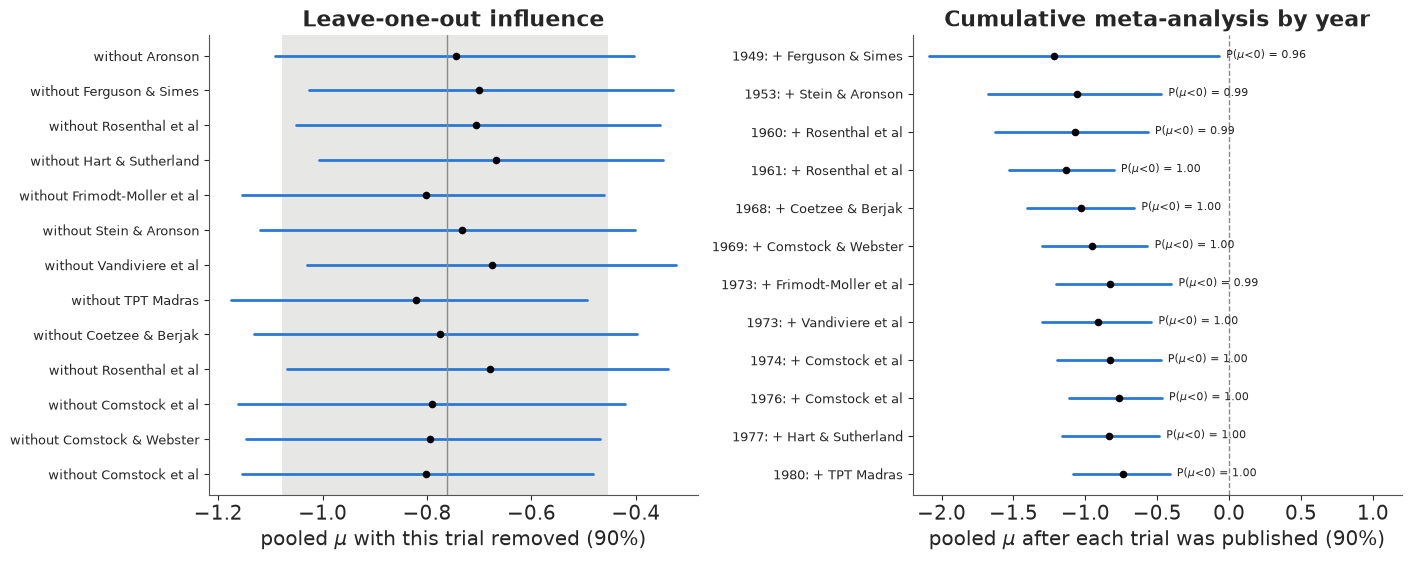

In [11]:
full_lo, full_med, full_hi = np.quantile(MU, [0.05, 0.5, 0.95])
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
ax = axes[0]
for row, (name, (lo, med, hi), p_neg) in enumerate(loo_rows[::-1]):
    ax.plot([lo, hi], [row, row], color=BLUE, lw=2)
    ax.scatter(med, row, color="k", zorder=3, s=20)
ax.axvspan(full_lo, full_hi, color=GREY, alpha=0.2, lw=0)
ax.axvline(full_med, color=GREY, lw=1)
ax.set(yticks=range(K), xlabel="pooled $\\mu$ with this trial removed (90%)", title="Leave-one-out influence")
ax.set_yticklabels([f"without {r[0]}" for r in loo_rows[::-1]], fontsize=9)

ax = axes[1]
for row, (year, name, (lo, med, hi), p_neg) in enumerate(cum_rows):
    ax.plot([lo, hi], [row, row], color=BLUE, lw=2)
    ax.scatter(med, row, color="k", zorder=3, s=20)
    ax.text(hi + 0.05, row, f"P($\\mu$<0) = {p_neg:.2f}", va="center", fontsize=8)
ax.axvline(0, color=GREY, lw=1, ls="--")
ax.set(yticks=range(len(cum_rows)), xlabel="pooled $\\mu$ after each trial was published (90%)",
       title="Cumulative meta-analysis by year", xlim=(-2.2, 1.2))
ax.set_yticklabels([f"{r[0]}: + {r[1]}" for r in cum_rows], fontsize=9)
ax.invert_yaxis();

Read the left panel against the grey band (the full-data posterior): no single trial moves
the pooled estimate outside it, which is the reassurance one wants. Read the right panel
top to bottom: the case for the vaccine was already strong by the early 1950s, and the
177,000-participant Madras trial of 1980 (odds ratio 1.0) pulled the average towards zero
without coming close to overturning it - the random-effects model treats it as one more
setting, not as the final word.

## 6 · What the database cannot tell you: small-study effects

A database of *published* studies has a blind spot: studies that were never published.
The classic demonstration is intravenous magnesium after a heart attack. Through the early
1990s, a meta-analysis of small trials found a large mortality benefit, and a 1993 paper
called it an "effective, safe, simple and inexpensive" treatment. Then ISIS-4 randomised
58,050 patients and found nothing. Egger et al. (2001) assembled the 16 trials to study
what went wrong.

The **funnel plot** puts each trial's effect against its standard error, so precise trials
sit at the top near the truth and imprecise ones fan out symmetrically below - *if* what
was published is all that was run. A Bayesian **Egger model** adds a term
$\gamma\,s_k$ to the trial effect: $\gamma$ is the small-study slope, and $\mu$ becomes the
effect a trial of infinite precision would find.

In [12]:
data.describe("magnesium")
mg = data.load("magnesium")
a2, n1, c2, n2 = (mg[col].to_numpy(float) for col in ["ai", "n1i", "ci", "n2i"])
cc = 0.5 * ((a2 == 0) | (c2 == 0))               # continuity correction only where a cell is zero
y2 = np.log(((a2 + cc) / (n1 - a2 + cc)) / ((c2 + cc) / (n2 - c2 + cc)))
se2 = np.sqrt(1 / (a2 + cc) + 1 / (n1 - a2 + cc) + 1 / (c2 + cc) + 1 / (n2 - c2 + cc))
mg_names = mg.study.to_numpy(dtype=object)


def normal_re(y_, se_, names, slope=None, name="re"):
    with pm.Model(coords={"trial": names}, name=name) as m:
        mu = pm.Normal("mu", 0, 1.5)
        tau = pm.HalfNormal("tau", 1)
        z = pm.Normal("z", 0, 1, dims="trial")
        shift = pm.Normal("gamma", 0, 2) * slope if slope is not None else 0.0
        pm.Normal("y", mu + shift + tau * z, se_, observed=y_, dims="trial")
    return m


id_all = fit(normal_re(y2, se2, mg_names, name="all16"))
id_small = fit(normal_re(y2[:-1], se2[:-1], mg_names[:-1], name="without_ISIS4"))
id_egger = fit(normal_re(y2, se2, mg_names, slope=se2, name="egger"))
GAMMA = stacked(id_egger.posterior["egger::gamma"])
print(f"small-study slope gamma: median {np.median(GAMMA):.2f}, P(gamma < 0) = {(GAMMA < 0).mean():.3f}")

magnesium: 16 trials: deaths and patients per arm, including the 58,050-patient ISIS-4 mega-trial.
  source: Egger, Davey Smith & Altman (2001), intravenous magnesium after myocardial infarction, via `metadat`.
  url:    https://raw.githubusercontent.com/wviechtb/metadat/master/data-raw/dat.egger2001.txt


  all16: divergences = 0


  without_ISIS4: divergences = 0


  egger: divergences = 14
small-study slope gamma: median -1.35, P(gamma < 0) = 0.998


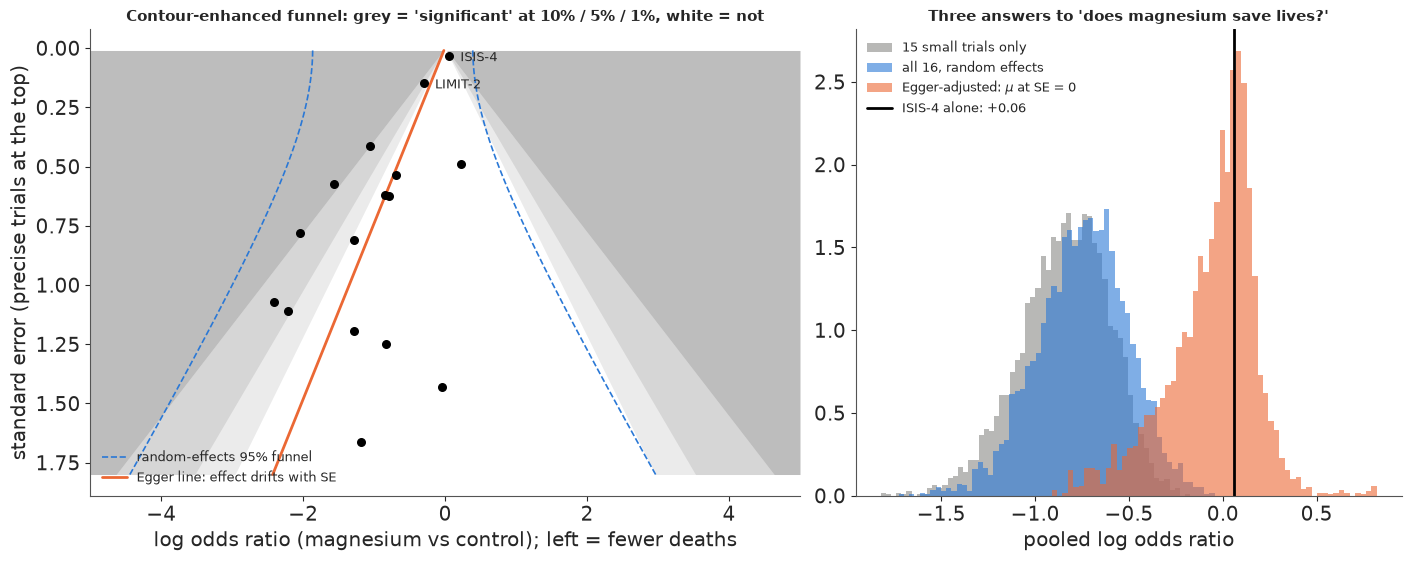

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1.3, 1]})
ax = axes[0]
se_grid = np.linspace(0.01, 1.8, 100)
# contour-enhanced funnel (Peters et al. 2008): shade where a trial with this SE is "significant",
# darker for smaller p; the central white wedge is p > 0.1. Missing trials in the white wedge = suspicious.
z_cuts = [stats.norm.ppf(1 - p / 2) for p in (0.1, 0.05, 0.01)] + [np.inf]
for (z_lo, z_hi), shade in zip(zip(z_cuts[:-1], z_cuts[1:]), (0.08, 0.16, 0.26)):
    for sign in (-1, 1):
        ax.fill_betweenx(se_grid, sign * z_lo * se_grid, np.clip(sign * z_hi * se_grid, -5, 5), color="k", alpha=shade, lw=0)
mu_all, tau_all = np.median(stacked(id_all.posterior["all16::mu"])), np.median(stacked(id_all.posterior["all16::tau"]))
ax.plot(mu_all - 1.96 * np.sqrt(se_grid**2 + tau_all**2), se_grid, color=BLUE, ls="--", lw=1.2)
ax.plot(mu_all + 1.96 * np.sqrt(se_grid**2 + tau_all**2), se_grid, color=BLUE, ls="--", lw=1.2, label="random-effects 95% funnel")
mu_e = np.median(stacked(id_egger.posterior["egger::mu"]))
ax.plot(mu_e + np.median(GAMMA) * se_grid, se_grid, color=ORANGE, lw=2, label="Egger line: effect drifts with SE")
ax.scatter(y2, se2, color="k", s=30, zorder=3)
for j in [13, 15]:
    ax.annotate(mg_names[j], (y2[j], se2[j]), xytext=(8, -4), textcoords="offset points", fontsize=9)
ax.invert_yaxis()
ax.set(xlabel="log odds ratio (magnesium vs control); left = fewer deaths", ylabel="standard error (precise trials at the top)",
       xlim=(-5, 5))
ax.set_title("Contour-enhanced funnel: grey = 'significant' at 10% / 5% / 1%, white = not", fontsize=11)
ax.legend(fontsize=9, loc="lower left")

ax = axes[1]
for idata, pre, col, lab in [(id_small, "without_ISIS4::", GREY, "15 small trials only"),
                             (id_all, "all16::", BLUE, "all 16, random effects"),
                             (id_egger, "egger::", ORANGE, "Egger-adjusted: $\\mu$ at SE = 0")]:
    ax.hist(stacked(idata.posterior[pre + "mu"]), bins=60, density=True, alpha=0.6, color=col, label=lab)
ax.axvline(y2[-1], color="k", lw=2, label=f"ISIS-4 alone: {y2[-1]:+.2f}")
ax.set(xlabel="pooled log odds ratio")
ax.set_title("Three answers to 'does magnesium save lives?'", fontsize=11)
ax.legend(fontsize=9);

The small trials sit almost entirely in the lower-left: the imprecise ones all found large
benefits, exactly the asymmetry a mix of publication bias and small-trial quality problems
produces, and the slope $\gamma$ is decisively negative. The random-effects model on all 16
trials still says "magnesium halves mortality" because it treats ISIS-4 as one trial among
many; the Egger-adjusted $\mu$ says "no effect", which is what ISIS-4 found. Neither model
*knows* which is right - the adjustment is a hypothesis about the missing studies - but a
funnel this lopsided is the database telling you what it does not contain.

## 7 · When the database protects privacy harder than it needs to

Section 1 showed that releasing the counts costs nothing. Real data custodians often go
further, because a count of 1 in a small cell *can* be identifying when combined with other
releases. Two common mechanisms, and how to model each so the analysis stays honest:

### 7.1 Small-cell suppression: "fewer than 10"

Cells below a threshold are published as "<10". A suppressed cell is not missing, it is
**interval-censored**: we know the count is in $\{0, \ldots, 9\}$. `pm.Censored` around the
Binomial does exactly this: an observation at the bound contributes $P(X \le 9)$ instead of
$P(X = x)$.

In [14]:
THR = 10
suppressed_t, suppressed_c = a < THR, c < THR
print(f"cells published as '<{THR}': {suppressed_t.sum()} BCG-arm and {suppressed_c.sum()} control-arm counts "
      f"({', '.join(bcg.author[suppressed_t | suppressed_c])})")

with pm.Model(coords=coords, name="suppressed") as suppressed:
    mu = pm.Normal("mu", 0, 1.5)
    tau = pm.HalfNormal("tau", 1)
    z = pm.Normal("z", 0, 1, dims="trial")
    theta = pm.Deterministic("theta", mu + tau * z, dims="trial")
    alpha = pm.Normal("alpha", -4, 2, dims="trial")
    # lower=THR-1 where suppressed: an observed value of THR-1 then means "at most THR-1"
    pm.Censored("cases_c", pm.Binomial.dist(n=c + d, p=pm.math.invlogit(alpha)),
                lower=np.where(suppressed_c, THR - 1, -1), upper=None,
                observed=np.where(suppressed_c, THR - 1, c), dims="trial")
    pm.Censored("cases_t", pm.Binomial.dist(n=a + b, p=pm.math.invlogit(alpha + theta)),
                lower=np.where(suppressed_t, THR - 1, -1), upper=None,
                observed=np.where(suppressed_t, THR - 1, a), dims="trial")
    pm.Deterministic("theta_new", mu + tau * pm.Normal("z_new", 0, 1))
idata_s = fit(suppressed)

cells published as '<10': 5 BCG-arm and 1 control-arm counts (Aronson, Ferguson & Simes, Rosenthal et al, Vandiviere et al, Comstock & Webster)


  suppressed: divergences = 1


full counts  mu = -0.76 [-1.08, -0.45]   tau = 0.62
suppressed   mu = -0.84 [-1.33, -0.47]   tau = 0.69


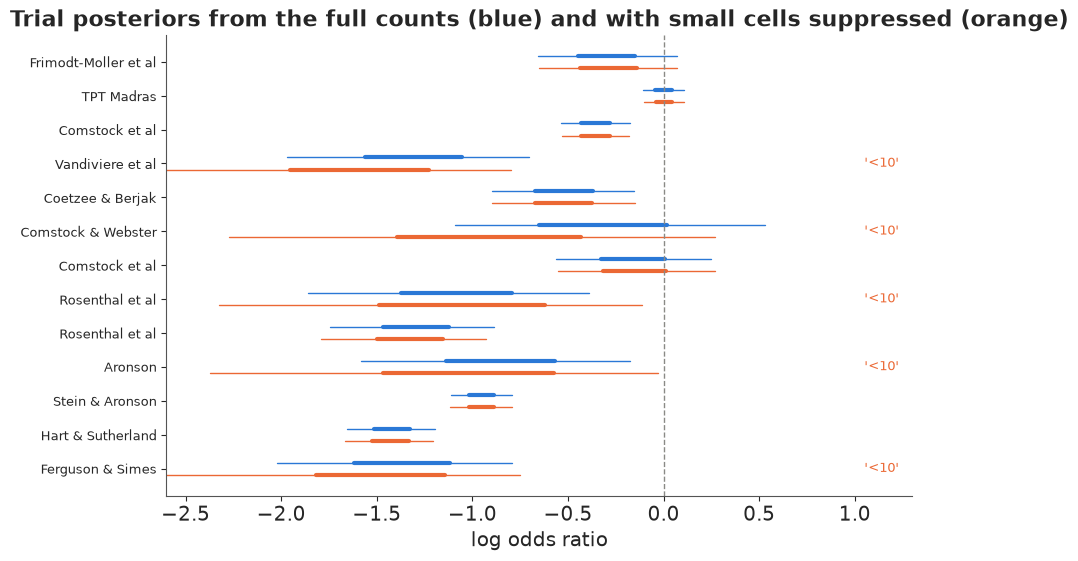

In [15]:
TH_full = stacked(idata_1.posterior["one_stage::theta"])
TH_sup = stacked(idata_s.posterior["suppressed::theta"])
fig, ax = plt.subplots(figsize=(9, 5.5))
yy = np.arange(K)[::-1]
for row, i in zip(yy, order):
    for S, off, col in [(TH_full, 0.18, BLUE), (TH_sup, -0.18, ORANGE)]:
        lo, q1, q3, hi = np.quantile(S[:, i], [0.05, 0.25, 0.75, 0.95])
        ax.plot([lo, hi], [row + off, row + off], color=col, lw=1)
        ax.plot([q1, q3], [row + off, row + off], color=col, lw=3)
    if suppressed_t[i] or suppressed_c[i]:
        ax.text(1.05, row, f"'<{THR}'", color=ORANGE, fontsize=9, va="center")
ax.axvline(0, color=GREY, lw=1, ls="--")
ax.set(yticks=yy, xlabel="log odds ratio", xlim=(-2.6, 1.3),
       title="Trial posteriors from the full counts (blue) and with small cells suppressed (orange)")
ax.set_yticklabels(list(coords["trial"][order]), fontsize=9)
for pre, idata, lab in [("one_stage::", idata_1, "full counts"), ("suppressed::", idata_s, "suppressed")]:
    m = stacked(idata.posterior[pre + "mu"])
    print(f"{lab:12s} mu = {np.median(m):.2f} [{np.quantile(m, 0.05):.2f}, {np.quantile(m, 0.95):.2f}]   "
          f"tau = {np.median(stacked(idata.posterior[pre + 'tau'])):.2f}")

Suppression widens the affected trials' posteriors a lot and the pooled interval a little
(its lower end moves from -1.1 to -1.3; the median by less than 0.1): the cells under 10
belong to the small trials, which carried little weight to begin with. The important thing
is what did *not* happen: a censored likelihood does not bias the estimate, whereas treating
"<10" as 9, or as 5, or dropping those trials, would.

### 7.2 Differential privacy: calibrated noise on every count

Differential privacy gives a formal guarantee - the released numbers are almost equally
likely whether or not any one person took part - by adding noise before release. With the
Gaussian mechanism, each case count gets $\text{Normal}(0, \sigma_{\text{DP}})$ noise with
$\sigma_{\text{DP}} = \sqrt{2\ln(1.25/\delta)}\,/\,\varepsilon$; smaller $\varepsilon$ means
stronger privacy and more noise. (The enrolment totals are treated as public.)

The released count is then $\tilde{x}_k = x_k + e_k$, and the analyst's model must include
$e_k$. A count is approximately $\text{Normal}(np,\ np(1-p))$, and adding independent noise
just adds $\sigma_{\text{DP}}^2$ to that variance, so the **noise-aware** model is one line
different from a **naive** one that pretends the noisy counts are exact. We sweep
$\varepsilon$ from generous to strict, with one noise draw per level, and fit both models.

In [16]:
DELTA = 1e-5
epsilons = np.array([4, 2, 1, 0.5, 0.25, 0.1])
sigmas = np.sqrt(2 * np.log(1.25 / DELTA)) / epsilons


def dp_model(noisy_t, noisy_c, sigma_dp, aware):
    with pm.Model(coords=coords, name="dp_aware" if aware else "dp_naive") as m:
        mu = pm.Normal("mu", 0, 1.5)
        tau = pm.HalfNormal("tau", 1)
        z = pm.Normal("z", 0, 1, dims="trial")
        theta = pm.Deterministic("theta", mu + tau * z, dims="trial")
        alpha = pm.Normal("alpha", -4, 2, dims="trial")
        p_c, p_t = pm.math.invlogit(alpha), pm.math.invlogit(alpha + theta)
        extra = sigma_dp**2 if aware else 0.0
        pm.Normal("cases_c", (c + d) * p_c, pm.math.sqrt((c + d) * p_c * (1 - p_c) + extra), observed=noisy_c, dims="trial")
        pm.Normal("cases_t", (a + b) * p_t, pm.math.sqrt((a + b) * p_t * (1 - p_t) + extra), observed=noisy_t, dims="trial")
    return m


dp_results = []
for eps, sig in zip(epsilons, sigmas):
    noisy_t, noisy_c = a + rng.normal(0, sig, K), c + rng.normal(0, sig, K)
    print(f"epsilon = {eps:<5} sigma_DP = {sig:5.1f}", end="")
    row = {"eps": eps, "sigma": sig}
    for aware in (True, False):
        with dp_model(noisy_t, noisy_c, sig, aware):
            id_dp = pm.sample(target_accept=0.95, random_seed=RANDOM_SEED, progressbar=False)
        pre = "dp_aware::" if aware else "dp_naive::"
        row["aware" if aware else "naive"] = np.quantile(stacked(id_dp.posterior[pre + "mu"]), [0.05, 0.5, 0.95])
        row[("aware" if aware else "naive") + "_theta_sd"] = stacked(id_dp.posterior[pre + "theta"]).std(0)
        print(f"   {'aware' if aware else 'naive'} div = {int(id_dp.sample_stats['diverging'].sum())}", end="")
    print()
    dp_results.append(row)

epsilon = 4.0   sigma_DP =   1.2

   aware div = 0

   naive div = 0
epsilon = 2.0   sigma_DP =   2.4

   aware div = 0

   naive div = 0
epsilon = 1.0   sigma_DP =   4.8

...

   naive div = 0
epsilon = 0.25  sigma_DP =  19.4

   aware div = 0

   naive div = 0
epsilon = 0.1   sigma_DP =  48.4

   aware div = 0

   naive div = 0


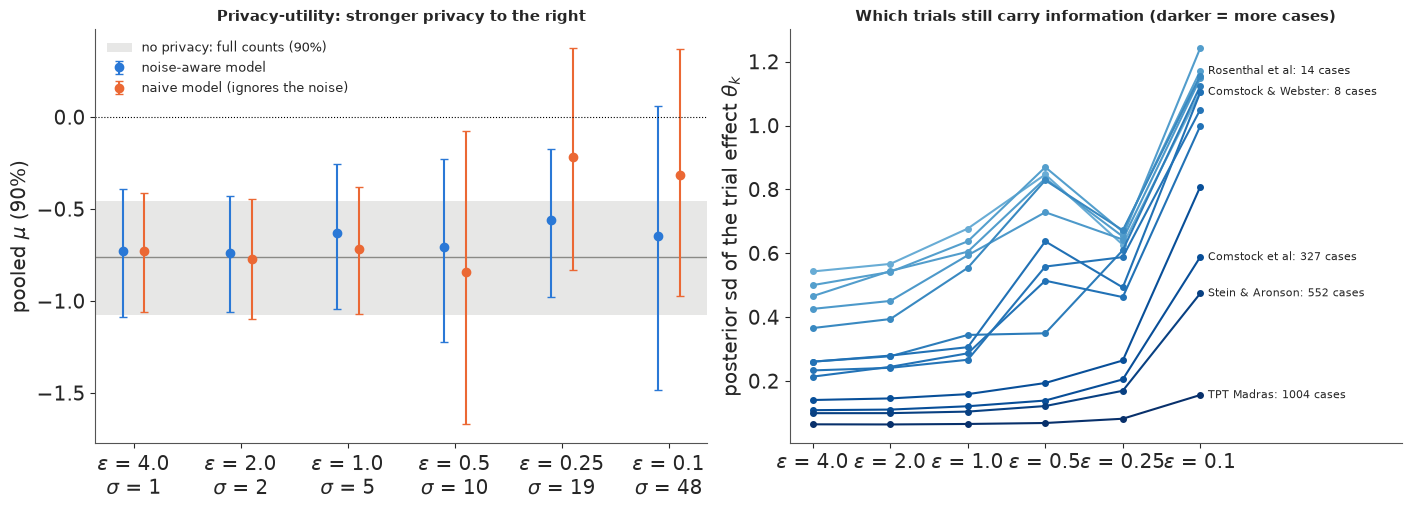

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
x = np.arange(len(epsilons))
ax.axhspan(full_lo, full_hi, color=GREY, alpha=0.2, lw=0, label="no privacy: full counts (90%)")
ax.axhline(full_med, color=GREY, lw=1)
for key, col, off, lab in [("aware", BLUE, -0.1, "noise-aware model"), ("naive", ORANGE, 0.1, "naive model (ignores the noise)")]:
    lo, med, hi = np.array([r[key] for r in dp_results]).T
    ax.errorbar(x + off, med, yerr=[med - lo, hi - med], fmt="o", color=col, capsize=3, label=lab)
ax.axhline(0, color="k", lw=0.8, ls=":")
ax.set(xticks=x, xticklabels=[f"$\\varepsilon$ = {e}\n$\\sigma$ = {s:.0f}" for e, s in zip(epsilons, sigmas)],
       ylabel="pooled $\\mu$ (90%)")
ax.set_title("Privacy-utility: stronger privacy to the right", fontsize=11)
ax.legend(fontsize=9, loc="upper left")

ax = axes[1]
n_cases = a + c                                   # what the noise competes with: the number of events
cmap = plt.get_cmap("Blues")
label_these = np.r_[np.argsort(n_cases)[:2], np.argsort(n_cases)[-3:]]
for i in np.argsort(n_cases):
    sd_path = [r["aware_theta_sd"][i] for r in dp_results]
    ax.plot(x, sd_path, marker="o", ms=4, lw=1.5, color=cmap(0.3 + 0.7 * np.log(n_cases[i]) / np.log(n_cases.max())))
    if i in label_these:
        ax.text(x[-1] + 0.1, sd_path[-1], f"{coords['trial'][i]}: {int(n_cases[i])} cases", fontsize=8, va="center")
ax.set(xticks=x, xticklabels=[f"$\\varepsilon$ = {e}" for e in epsilons], ylabel="posterior sd of the trial effect $\\theta_k$",
       xlim=(-0.3, len(x) + 1.6))
ax.set_title("Which trials still carry information (darker = more cases)", fontsize=11);

Two lessons, one for each panel. **Left:** the naive analysis does not merely get noisier
as privacy tightens - its estimate drifts towards *no effect* (noise added to a count of 4
cases reads as a weaker contrast: the classical attenuation of measurement error), and its
interval has no way of knowing that. The noise-aware model stays centred near the full-data
answer at every $\varepsilon$ and widens instead: its interval *is* the price of the
privacy, stated in the units of the question. **Right:** what protects a trial from the
noise is its number of *cases*, not its number of participants. Tuberculosis is rare, so a
trial of 26,000 people may hold only 62 cases and lose most of its precision at
$\varepsilon \le 0.25$; only Madras, with a thousand cases, is nearly untouched. A database
that adds noise should say so in its metadata, because the analyst *can* account for it -
but only if told.

(One noise realisation per $\varepsilon$ is enough to make the point; a proper evaluation
would average the curve over many draws of the noise. That is one of the exercises.)

## 8 · Studies inside studies: a three-level model

Many databases have structure above the study: trials from the same research group, sites
within a multi-centre trial, or here 56 studies of modified school calendars nested in 11
school districts. Two variance components - between districts and between studies within a
district - and the question of how much of the heterogeneity lives at each level.

In [18]:
data.describe("konstantopoulos")
ko = data.load("konstantopoulos")
districts = np.sort(ko.district.unique())
d_idx = pd.Index(districts).get_indexer(ko.district)

with pm.Model(coords={"district": districts.astype(str), "study": ko.study.to_numpy()}, name="three_level") as three_level:
    mu = pm.Normal("mu", 0, 1)
    tau_d = pm.HalfNormal("tau_district", 0.5)
    tau_s = pm.HalfNormal("tau_study", 0.5)
    delta = pm.Deterministic("delta", mu + tau_d * pm.Normal("zd", 0, 1, dims="district"), dims="district")
    theta = pm.Deterministic("theta", delta[d_idx] + tau_s * pm.Normal("zs", 0, 1, dims="study"), dims="study")
    pm.Normal("y", theta, np.sqrt(ko.vi.to_numpy()), observed=ko.yi.to_numpy(), dims="study")
    pm.Deterministic("icc", tau_d**2 / (tau_d**2 + tau_s**2))
idata_3 = fit(three_level)
az.summary(idata_3, var_names=["three_level::mu", "three_level::tau_district", "three_level::tau_study", "three_level::icc"],
           ci_kind="hdi", ci_prob=0.9, round_to=2)

konstantopoulos: 56 studies nested in 11 school districts: standardised mean difference, its variance, year.
  source: Konstantopoulos (2011), modified school calendars and achievement, via `metadat`.
  url:    https://raw.githubusercontent.com/wviechtb/metadat/master/data-raw/dat.konstantopoulos2011.txt


  three_level: divergences = 0


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
three_level::mu,0.18,0.09,0.03,0.33,372.67,590.93,1.02,0.00,0.0
three_level::tau_district,0.28,0.08,0.16,0.41,567.25,934.71,1.01,0.00,0.0
three_level::tau_study,0.19,0.03,0.13,0.24,894.87,1393.65,1.00,0.00,0.0
three_level::icc,0.66,0.15,0.43,0.89,598.82,1111.89,1.00,0.01,0.0


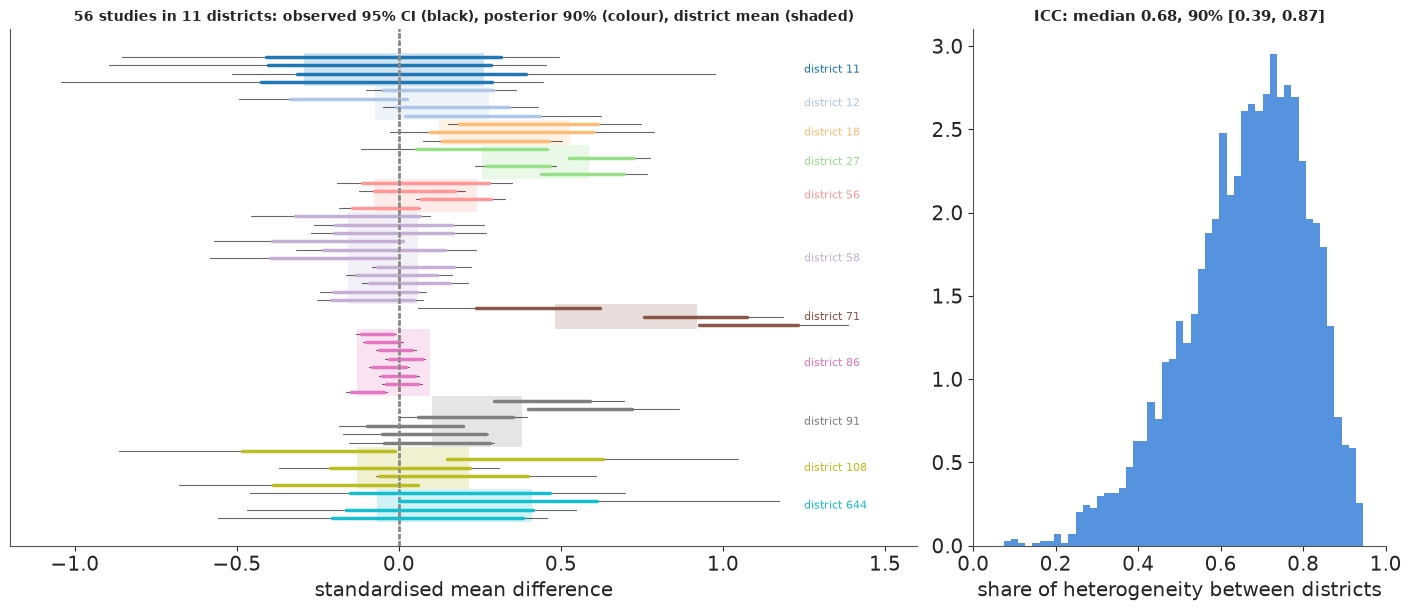

In [19]:
DELTA_ = stacked(idata_3.posterior["three_level::delta"])
TH3 = stacked(idata_3.posterior["three_level::theta"])
ICC = stacked(idata_3.posterior["three_level::icc"])
cmap = plt.get_cmap("tab20")
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [2.2, 1]})
ax = axes[0]
row = 0
for j, dname in enumerate(districts):
    members = np.where(d_idx == j)[0]
    col = cmap(j / len(districts))
    lo, hi = np.quantile(DELTA_[:, j], [0.05, 0.95])
    ax.fill_betweenx([row - 0.5, row + len(members) - 0.5], lo, hi, color=col, alpha=0.2, lw=0)
    ax.axvline(0, color=GREY, lw=1, ls="--")
    for s in members:
        yi, sei = ko.yi[s], np.sqrt(ko.vi[s])
        ax.plot([yi - 1.96 * sei, yi + 1.96 * sei], [row, row], color="k", lw=0.8, alpha=0.6)
        ax.plot(np.quantile(TH3[:, s], [0.05, 0.95]), [row, row], color=col, lw=2.5)
        row += 1
    ax.text(1.25, row - len(members) / 2 - 0.5, f"district {dname}", va="center", fontsize=8, color=col)
ax.set(yticks=[], xlim=(-1.2, 1.6), xlabel="standardised mean difference")
ax.set_title("56 studies in 11 districts: observed 95% CI (black), posterior 90% (colour), district mean (shaded)", fontsize=10)
ax.invert_yaxis()
axes[1].hist(ICC, bins=50, color=BLUE, alpha=0.8, density=True)
axes[1].set(xlabel="share of heterogeneity between districts", xlim=(0, 1))
axes[1].set_title(f"ICC: median {np.median(ICC):.2f}, 90% [{np.quantile(ICC, 0.05):.2f}, {np.quantile(ICC, 0.95):.2f}]", fontsize=11);

Most of the heterogeneity is between districts, not between studies within one: a study's
result tells you more about its district than about the intervention in general, and a
two-level model that ignored the districts would report a $\tau$ that mixes the two and an
interval for $\mu$ that is too narrow (11 districts, not 56 studies, are the effective
sample size for the top level).

## 9 · Summary

| Question | Display / model |
|---|---|
| What did each study find and what do we now believe about it? | forest plot: observed CI, shrunken posterior, pooled diamond, **prediction interval** |
| How different are the studies? | posterior of $\tau$ and $I^2$; the predictive distribution of a new trial |
| Why are they different? | meta-regression on a study-level covariate; residual $\tau$ |
| Does one study drive the answer? When did we know? | leave-one-out influence; cumulative meta-analysis |
| What is missing from the database? | contour-enhanced funnel; a small-study slope (Egger) |
| Studies within groups? | three-level model; ICC |
| Counts are all we get - do we lose anything? | no: they are sufficient statistics (section 1) |
| Counts are suppressed or noised - what then? | censored likelihood; noise-aware likelihood; measure the loss (section 7) |

## Try it yourself

1. **Average over the noise.** Repeat the $\varepsilon$ sweep of section 7.2 with ten noise
   draws per level and plot the mean and spread of the posterior sd of $\mu$ against
   $\varepsilon$. At what $\varepsilon$ does the noise-aware posterior first become wider
   than the "15 small trials only" magnesium posterior of section 6?
2. **The Laplace mechanism.** Pure $\varepsilon$-DP adds Laplace($1/\varepsilon$) noise
   instead of Gaussian. Write the noise-aware likelihood with a Laplace error term (a
   `pm.CustomDist` of Binomial-normal-approximation plus Laplace, or a latent true count
   with a Normal approximation) and compare the two mechanisms at equal $\varepsilon$.
3. **Magnesium in one stage.** Refit section 6 with the binomial one-stage model and no
   continuity correction (the Bertschat trial has zero deaths in one arm). Does the
   Egger-type adjustment still say "no effect" when the slope is put on $\sqrt{1/n_k}$
   instead of the estimated standard error?